# Task 1: RNA-Seq QC & Normalization

**Goal:** Quality-control the raw RSEM counts and normalize using DESeq2-style median-of-ratios size factors, followed by log2 transformation.

**Normalization strategy:**
- **DESeq2 median-of-ratios**: computes a per-sample size factor as the median ratio of each sample's counts to the gene-wise geometric mean across all samples. This corrects for both sequencing depth *and* RNA composition bias (unlike simple CPM).
- After size-factor normalization, apply `log2(x + 1)` to stabilize variance for clustering and visualization.

Steps:
1. Load raw RNA-Seq data
2. QC: inspect read depth distribution, flag outlier samples
3. Filter lowly expressed genes
4. Compute DESeq2 size factors and normalize
5. Log2 transform
6. Save processed data to `processed/`

In [1]:
import sys
from pathlib import Path

# Robustly locate project root whether Jupyter is launched from notebooks/ or project root
cwd = Path.cwd()
project_root = cwd if (cwd / 'src').exists() else cwd.parent
sys.path.insert(0, str(project_root))

import pandas as pd
import matplotlib.pyplot as plt

from src.data_utils import load_rna, save_processed
from src.normalization import qc_summary, filter_low_expression, normalize_deseq2, log_transform
from src.plotting import plot_qc_distributions, save_fig

print(f"Project root: {project_root}")

Project root: /Users/akanksha/Desktop/ws/dev/local/project1


## 1. Load raw data

In [2]:
rna_raw = load_rna()
print(rna_raw.shape)
rna_raw.head()

(1212, 20504)


,bcr_patient_barcode,sample_type,A1BG,A1CF,A2BP1,A2LD1,A2ML1,A2M,A4GALT,A4GNT,...,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3,psiTPTE22,tAKR
patient_id,,,,,,,,,,,,,,,,,,,,,
TCGA-3C-AAAU,TCGA-3C-AAAU-01A-11R-A41B-07,Primary Tumor,197.0897,0.0000,0.0000,102.9634,1.3786,5798.3746,68.2424,8.6165,...,129.5917,1007.7824,1658.4983,258.4941,1208.3738,3507.2482,1894.9342,1180.4565,1.7233,0.0
TCGA-3C-AALI,TCGA-3C-AALI-01A-11R-A41B-07,Primary Tumor,237.3844,0.0000,0.0000,70.8646,4.3502,7571.9793,157.6944,0.5438,...,59.8151,448.6134,1343.1213,198.4774,603.5889,5504.6221,1318.6514,406.7428,926.5905,0.0
TCGA-3C-AALJ,TCGA-3C-AALJ-01A-31R-A41B-07,Primary Tumor,423.2366,0.9066,0.0000,161.2602,0.0000,8840.3989,573.8894,0.0000,...,35.3581,533.9982,768.8123,331.8223,532.1850,5458.7489,942.8830,509.5195,35.3581,0.0
TCGA-3C-AALK,TCGA-3C-AALK-01A-11R-A41B-07,Primary Tumor,191.0178,0.0000,0.0000,62.5072,1.6549,10960.2193,506.4129,0.0000,...,55.0269,437.7327,863.8808,175.4241,607.3645,5691.3529,781.1336,700.8688,66.6115,0.0
TCGA-4H-AAAK,TCGA-4H-AAAK-01A-12R-A41B-07,Primary Tumor,268.8809,0.4255,3.8298,154.3702,3.4043,9585.4426,342.1277,0.4255,...,48.9362,424.2553,1049.7872,14.0426,775.7447,4041.7021,831.9149,881.7021,187.2340,0.0


## 2. QC: read depth and detected genes

In [3]:
gene_cols = [c for c in rna_raw.columns if c != 'sample_type' and c != 'bcr_patient_barcode']
qc = qc_summary(rna_raw, gene_cols)
qc.describe()

,total_counts,detected_genes,median_expression
count,1.212000e+03,1212.000000,1212.000000
mean,1.920905e+07,17583.870462,195.470758
std,1.482590e+06,340.409983,24.881774
min,1.611301e+07,15692.000000,116.706200
25%,1.824933e+07,17413.000000,178.779225
50%,1.898347e+07,17624.000000,195.321700
75%,1.982188e+07,17810.000000,213.761388
max,3.633170e+07,19279.000000,254.720050


In [4]:
len(gene_cols)

20502

Saved figure: figures/01_qc_raw.png


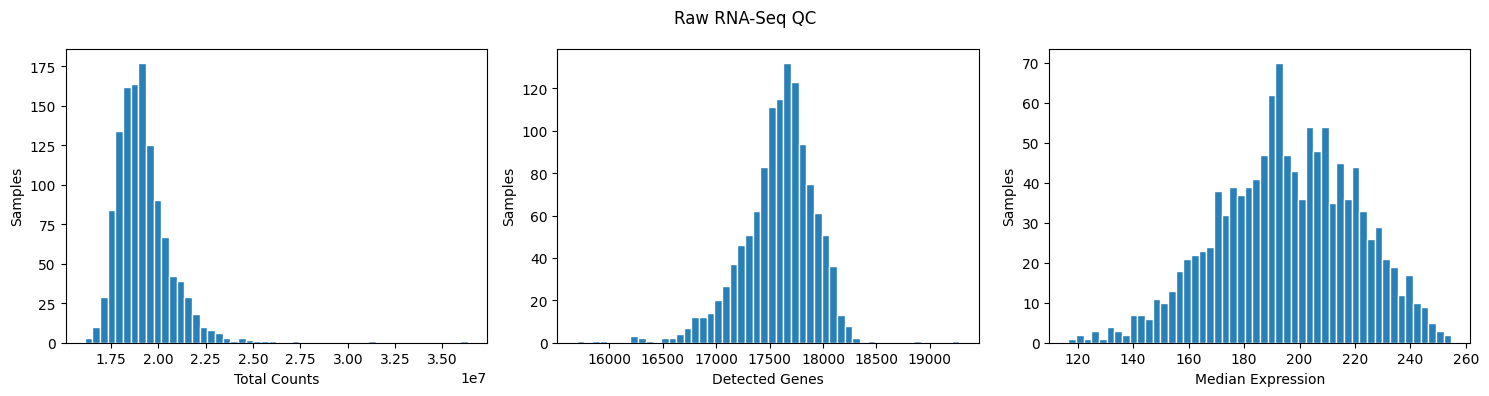

In [5]:
plot_qc_distributions(qc, title='Raw RNA-Seq QC')
save_fig('01_qc_raw')
plt.show()

## 3. Filter low-expression genes

In [6]:
rna_filtered = filter_low_expression(rna_raw, min_counts=1.0, min_samples_frac=0.1)
print(rna_filtered.shape)

Genes before filtering: 20502  |  after: 18200
(1212, 18201)


## 4. DESeq2 median-of-ratios normalization + Log2 transform

Size factors computed using 18200 genes (non-zero geometric mean).
Size factor range: [0.779, 1.169]
Saved figure: figures/01_size_factors.png


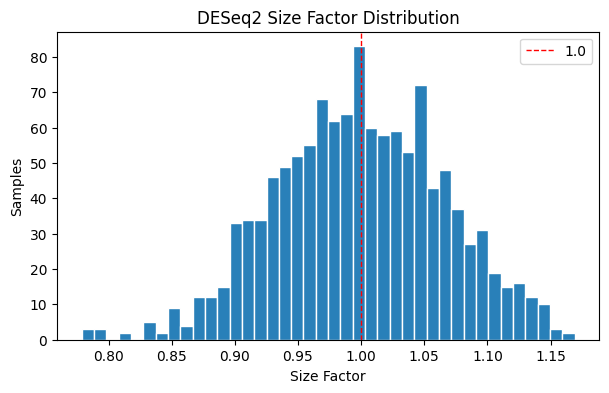

count    1212.000000
mean        0.998584
std         0.066960
min         0.778649
25%         0.952138
50%         0.997823
75%         1.046834
max         1.169142
dtype: float64


In [7]:
rna_norm, size_factors = normalize_deseq2(rna_filtered)

# Inspect size factors — should be centered around 1.0
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(size_factors, bins=40, edgecolor='white', color='#2980B9')
ax.axvline(1.0, color='red', linestyle='--', linewidth=1, label='1.0')
ax.set_xlabel('Size Factor')
ax.set_ylabel('Samples')
ax.set_title('DESeq2 Size Factor Distribution')
ax.legend()
save_fig('01_size_factors')
plt.show()

print(size_factors.describe())

In [9]:
size_factors

patient_id
TCGA-3C-AAAU    1.021862
TCGA-3C-AALI    1.039161
TCGA-3C-AALJ    1.032651
TCGA-3C-AALK    1.043334
TCGA-4H-AAAK    1.014152
                  ...   
TCGA-WT-AB44    0.977553
TCGA-XX-A899    1.081558
TCGA-XX-A89A    1.077698
TCGA-Z7-A8R5    1.112672
TCGA-Z7-A8R6    0.938889
Length: 1212, dtype: float64

In [11]:
from src.normalization import normalize_deseq2_pkg

# Compute size factors via pydeseq2 package (uses same filtered data)
_, sf_pkg = normalize_deseq2_pkg(rna_filtered, condition_col="sample_type")

# Our custom implementation's size factors (already computed above)
sf_custom = size_factors

# --- Scatter: custom vs pydeseq2 size factors ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(sf_custom, sf_pkg, alpha=0.4, s=10, color="#2980B9")
lims = [min(sf_custom.min(), sf_pkg.min()), max(sf_custom.max(), sf_pkg.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1, label='y = x')
axes[0].set_xlabel("Custom size factor")
axes[0].set_ylabel("pydeseq2 size factor")
axes[0].set_title("Size factor correlation (n={})".format(len(sf_custom)))
axes[0].legend()

# --- Difference distribution ---
diff = sf_custom - sf_pkg
axes[1].hist(diff, bins=40, edgecolor='white', color="#27AE60")
axes[1].axvline(0, color='red', linestyle='--', linewidth=1)
axes[1].set_xlabel("Custom − pydeseq2")
axes[1].set_ylabel("Samples")
axes[1].set_title(f"Size factor difference  (mean={diff.mean():.4f}, std={diff.std():.4f})")

plt.tight_layout()
save_fig('01_sizefactor_comparison')
plt.show()

print(f"Pearson r:  {sf_custom.corr(sf_pkg):.6f}")
print(f"Max abs diff: {diff.abs().max():.6f}")

/Users/akanksha/Desktop/ws/dev/local/project1/.venv/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
Fitting size factors...


Using None as control genes, passed at DeseqDataSet initialization


... done in 0.61 seconds.



KeyError: 'size_factors'

In [ ]:
# Log2 transform normalized counts
rna_log = log_transform(rna_norm)

qc_norm = qc_summary(rna_log, [c for c in rna_log.columns if c != 'sample_type'])
plot_qc_distributions(qc_norm, title='DESeq2-normalized & Log2-transformed QC')
save_fig('01_qc_normalized')
plt.show()

## 5. Save processed data

In [ ]:
save_processed(rna_log, 'rna_normalized')